# Load and explore the data

## Import libraries

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

## Load the data

##### Load the Seattle data set

In [2]:
df_seattle = pd.read_csv("/Users/anhtuyet15999/Projects/weather/data/raw/seattle_rain.csv")

##### Load the Boston data set

In [3]:
df_boston = pd.read_csv("/Users/anhtuyet15999/Projects/weather/data/raw/boston_rain.csv")

## Explore the contents of the data sets

##### Start by looking at the head of each data frame.

This will let us see the names of the columns and a few example values for each column.

##### Examine more rows

##### St. Louis data set

##### Are the columns are the same?

##### Use the `info` method to check the data types, size of the data frame, and numbers of missing values.

##### St. Louis data set

##### We can also compare data frame sizes using the shape attribute

## Why might the St. Louis data set be larger?

<pre>































</pre>

#### Examine the `STATION` column

In [4]:
df_seattle["STATION"].unique()

<ArrowStringArray>
['US1WAKG0225']
Length: 1, dtype: str

In [5]:
df_boston["STATION"].unique()

<ArrowStringArray>
['USC00198368']
Length: 1, dtype: str

##### How many unique stations are present?

#### Examine the `DATE` column

### Be careful to use correct data types

### Convert `DATE` to datetime

### What range of dates are present? => min, max, agg

### Are the data suitable for answering the question?

Plot the daily precipitation data for Seattle.

AttributeError: 'Text' object has no property 'frontsize'

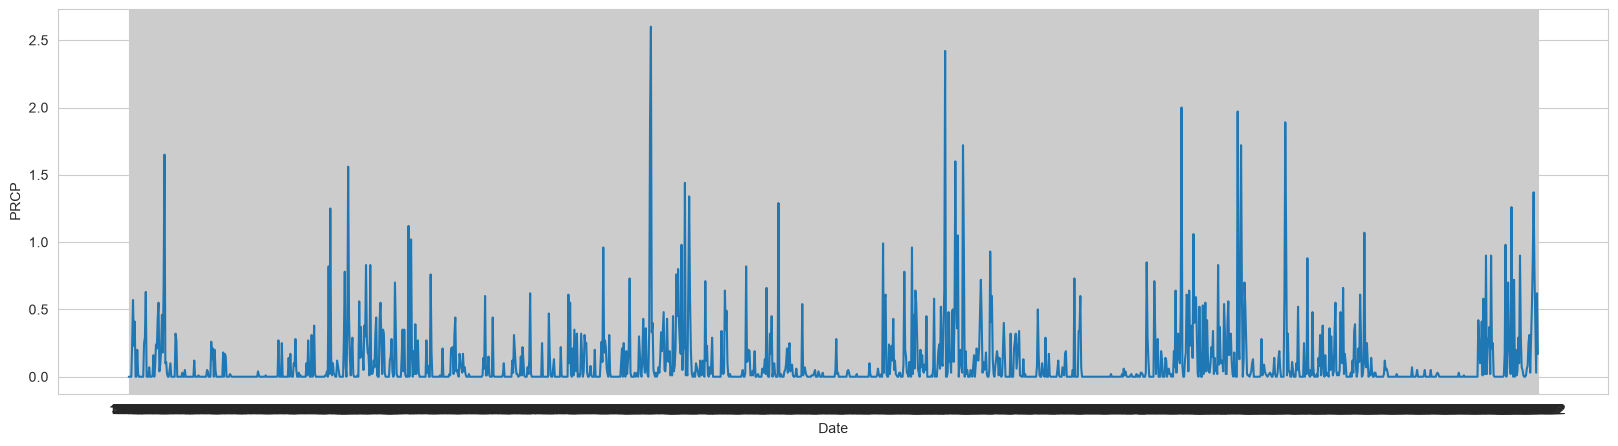

In [6]:
plt.figure(figsize=(20,5))

sns.lineplot(data=df_seattle, x='DATE', y='PRCP')

plt.xlabel("Date",frontsize=18) 
plt.ylabel("PRCP (inches)",frontsize=18) 

plt.tick_params(labelsize=15)
plt.show()


##### Plot the daily precipitation data for Boston

In [ ]:
plt.figure(figsize=(20,5))

sns.lineplot(data=df_boston, x='DATE', y='PRCP')

plt.xlabel("Date",fontsize=18) 
plt.ylabel("PRCP (inches)",fontsize=18)

plt.tick_params(labelsize=15)
plt.show()


## Tutorial: Selecting subsets of a DataFrame

In [ ]:
df_seattle.head()

### Select one column

Select the column containing precipitation `PRCP`.

#### Use dictionary-style indexing

#### Use explicit array-style indexing with loc

In [ ]:
#filter
#df_seattle = df_seattle.loc[df_seattle[Date > '

#### Use implicit array-style indexing with `.iloc`

What number column, starting with 0, is `PRCP`?

In [ ]:
df_seattle.head()

##### Use implicit array-style indexing with `.iloc`

### Select multiple columns

Select the columns containing `STATION`, `DATE`, and precipitation `PRCP`.

##### Use .loc

##### Use .iloc

#### Select a range of columns

Select all columns from `STATION` through `PRCP`

##### Use .iloc

### Select the first $n$ rows

Select the first 3 rows

Use the `.head()` method

##### Use explicit indexing

##### Use implicit indexing

### Select the last $n$ rows

Use the `.tail()` method

##### Use explicit indexing

##### Use implicit indexing

### Select rows using logical indexing

Select the rows where `PRCP` is greater than 0.

##### Select the rows where the precipitation is between 0.5 and 0.75 inches.

## Select relevant subsets of the data

We saw that the St. Louis data set contains data prior to 2018.

In [ ]:
df_stlouis.head()

##### Limit the St. Louis data to 2018 and beyond.

##### The St. Louis data set has values for many weather stations, while the Seattle data set has only one weather station.

We will focus on the data from the airport in St. Louis.

## Join data frames keeping `DATE` and `PRCP` columns

In [ ]:
df_seattle.head(2)

In [ ]:
df_stlouis.head(2)

**What type of join should we do?**

##### Use a join to keep all dates present

In [ ]:
#Outer join 2 files: 2 columns: date, prcp, outer join


Each DataFrame had a column named `PRCP`, so the default is to add suffixes _x and _y to differentiate the columns. Normally, I would rename the columns at this point to something more informative. However, I know that I want to convert the DataFrame to a tidy format and I will modify the names later.

### Create a tidy data frame with columns for city and precipitation

In [ ]:
df

In [ ]:
#use date as indentifier variable to change it into a tidy format
df = pd.melt(df, id_vars='DATE', var_name='city', value_name='precipitation')

How did this change the DataFrame?

In [ ]:
df.head()

### Rename columns or values to follow best practices

Rename the city values 'STL' and 'SEA'

In [7]:
df.loc[df[city]=='PRCP_x','city'] = 'BOT'

NameError: name 'df' is not defined

In [ ]:
df.loc[df[city]=='PRCP_y','city'] = 'SEA'

##### Rename the columns to be lowercase using `df.rename()`

In [ ]:
df = df.name(columns=['DATE': 'date'])

In [ ]:
df.head()

## Identify and fill in missing values

Data can be missing in multiple manners:
1. Values are `NaN` in the data frame

2.  Values are not included in the data set.

### Count the non-null or null values

Determine the number of non-null values in each column.

In [ ]:
df.notna().sum()

##### Determine the number of null values in each column.

In [ ]:
df.isna().sum()

##### Determine the number of null precipitation values for Seattle and St. Louis.

In [ ]:
df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum()

In [ ]:
df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum()

##### The St. Louis data set does not have any `NaN` values of `precipitation`. Are any dates omitted?

**How many data points should we have from 2018 to 2022?**

### Impute missing values

We will replace missing values with the mean across years of values on that day.


**Design an algorithm for replacing missing values with the mean across years of values on that day.**

In [ ]:
#Define a column that labels each day by day of the year:1,2,3...365
df['day of year'] = pd.DatetimeIndex(df['date']).day_of_year

In [ ]:
df.head()

In [ ]:
#compute the mean prec for each day in seattle
mean_day_prec = df.loc[
    df['city'] == 'SEA',
    'precipitation', 'day_of_year'].groupby().mean()

In [9]:
#plot: x=day of year, y=mean day prec
plt.figure(fig_size=(20.5))

sns.lineplot(data=mean_day_prec, x='day_of_year', y='precipitation')

AttributeError: Figure.set() got an unexpected keyword argument 'fig_size'

In [ ]:
indices = np.where(df['precipitation'].isna().

In [ ]:
df.isna().sum()

## Export the clean .csv file

In [ ]:
df.to_csv('clean_seattle_stlouis_weather.csv', encoding='utf-8-sig', index=False)